In [13]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import numpy as np 

In [34]:
img_path = os.path.join("DIC-C2DH-HeLa","01")
label_path = os.path.join("DIC-C2DH-HeLa","01_ST","SEG")
class CellSegDataSet(Dataset):
    def __init__(self,images_dir,annotations_dir,transforms = None):
        self.images_dir = images_dir
        self.annotations_dir = annotations_dir
        self.imgs = sorted([f for f in os.listdir(images_dir) if f.endswith('.tif')])
        self.masks = sorted([f for f in os.listdir(os.path.join(annotations_dir)) if f.endswith('.tif')])
        self.transforms = transforms
        self.to_tensor = T.ToTensor()
    def __getitem__(self, index):
        img_path = os.path.join(self.images_dir, self.imgs[index])
        mask_path = os.path.join(self.annotations_dir, self.masks[index])
        img = Image.open(img_path)
        msk = Image.open(mask_path)
        msk = self.to_tensor(msk)
        img = self.to_tensor(img)
        assert len(self.imgs) == len(self.masks)
        
        if self.transforms:
            img = self.transforms(img)
            msk = torch.from_numpy(np.array(msk)).long()
        
        return img,msk
    def __len__(self):
        return len(self.imgs)

dataset = CellSegDataSet(img_path,label_path)
img,msk = next(iter(dataset))

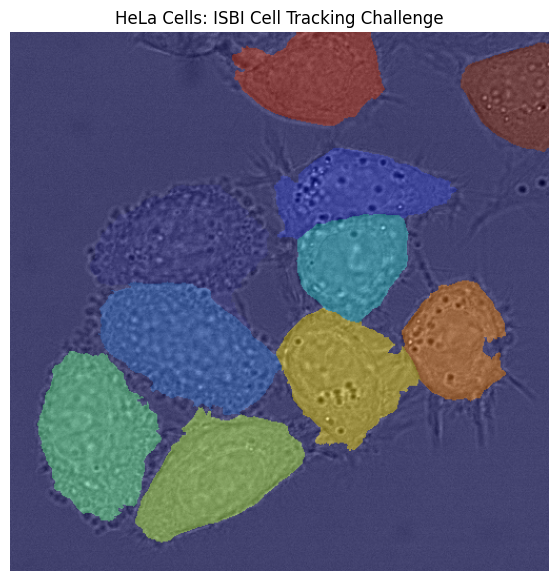

In [52]:
import matplotlib.pyplot as plt
import numpy as np

img_np = img.permute(1, 2, 0).numpy()
mask_np = msk.squeeze().numpy()

plt.figure(figsize=(7,7))

plt.imshow(img_np, cmap='gray')
plt.imshow(mask_np, cmap='jet', alpha=0.35)   # color mask on top

plt.title("HeLa Cells: ISBI Cell Tracking Challenge")
plt.axis("off")
plt.show()


In [47]:
msk.unique()

tensor([ 0,  1,  5,  7, 11, 15, 19, 23, 27, 32, 34], dtype=torch.int16)

In [33]:
dl = DataLoader(dataset,batch_size=10)
for batch_idx, (imgs, masks) in enumerate(dl):
    print("Batch", batch_idx)
    print("Images:", imgs.shape)   # [B, 1, H, W]
    print("Masks:", masks.shape)    # [B, H, W]
    break


Batch 0
Images: torch.Size([10, 1, 512, 512])
Masks: torch.Size([10, 1, 512, 512])
